<a href="https://colab.research.google.com/github/chingbsmtry11/First-Program/blob/main/Cross_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##EXERCISE
In the previous chapter i learned how to prepare numerical and categorical data for machine learning. I learned how to handle missing values using SimpleImputer and convert categorical variables using one-hot encoding. I also learned how to combine preprocessing and machine learning models using pipeline and machine learning models using Pipeline and ColumnTransformer. I build LRM, RFR and RR model and evaluated them using MAE, MSE, RMSE and R². And i also learn how to compare models with baseline.  I think cross-validation will solve diiferent types of models across multiple training/testing splits.

##STEP 1

In [38]:
import pandas as rb
import numpy as kb
import matplotlib.pyplot as fcb
csv_text = """patient_id,age,village,dosha_type,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,consultation_fee
P001,21,abc,kapha,56,150,110,80,4,400
P002,55,qwe,vata,55,167,120,70,3,300
P003,24,bnm,kapha,76,170,140,90,4,400
P004,34,mnb,vata,64,145,130,100,5,500
P005,76,abc,pitta,54,170,120,90,4,400
P006,33,abc,vata,77,169,130,100,2,200
P007,32,lkj,pitta,80,150,120,90,5,500
P008,66,hgf,kapha,86,144,140,100,3,300
P009,23,poi,pitta,46,150,140,100,4,400
P010,19,yui,vata,46,167,130,90,2,200
P011,45,lkj,pitta,76,163,120,80,3,300
P012,32,dfg,vata,55,150,110,90,5,500
P013,29,xcv,kapha,75,157,120,100,1,100
P014,34,vgy,vata,65,159,120,90,4,400
P015,26,wdv,vata,56,160,110,80,2,200
P016,54,ggf,kapha,54,165,110,90,3,300
P017,23,hdd,vata,63,170,120,90,4,400
P018,42,yug,kapha,66,180,110,90,2,200
P019,32,ghu,None,56,160,110,100,5,500
P020,34,None,pitta,54,170,110,80,3,300
P021,23,hdg,pitta,54,180,120,90,2,200
P022,53,ghg,vata,55,159,110,90,3,300
P023,35,abc,kapha,75,146,110,70,6,600
P024,44,abc,vata,86,168,120,80,3,300
P025,27,hjg,pitta,56,175,120,90,4,400
P026,25,kxs,kapha,46,187,130,100,5,500
P027,34,cxj,vata,74,190,120,90,3,300
P028,45,gfx,pitta,50,165,130,100,5,500
P029,26,wdv,vata,56,167,110,80,2,200
P030,23,hdd,vata,63,173,120,90,4,400
"""

with open("health_camp.csv", "w") as f:
  f.write(csv_text)
df = rb.read_csv("health_camp.csv")
df

,patient_id,age,village,dosha_type,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,consultation_fee
0,P001,21,abc,kapha,56,150,110,80,4,400
1,P002,55,qwe,vata,55,167,120,70,3,300
2,P003,24,bnm,kapha,76,170,140,90,4,400
3,P004,34,mnb,vata,64,145,130,100,5,500
4,P005,76,abc,pitta,54,170,120,90,4,400
5,P006,33,abc,vata,77,169,130,100,2,200
6,P007,32,lkj,pitta,80,150,120,90,5,500
7,P008,66,hgf,kapha,86,144,140,100,3,300
8,P009,23,poi,pitta,46,150,140,100,4,400
9,P010,19,yui,vata,46,167,130,90,2,200


##STEP 2

In [39]:
import pandas as rb
import numpy as kb
import matplotlib.pyplot as fcb
df = rb.read_csv("health_camp.csv")

print("Head:\n", df.head())
print("Shape:\n", df.shape)
print("Info:\n", df.info)
print("Null:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())


Head:
   patient_id  age village dosha_type  weight_kg  height_cm  \
0       P001   21     abc      kapha         56        150   
1       P002   55     qwe       vata         55        167   
2       P003   24     bnm      kapha         76        170   
3       P004   34     mnb       vata         64        145   
4       P005   76     abc      pitta         54        170   

   blood_pressure_systolic  blood_pressure_diastolic  visits  consultation_fee  
0                      110                        80       4               400  
1                      120                        70       3               300  
2                      140                        90       4               400  
3                      130                       100       5               500  
4                      120                        90       4               400  
Shape:
 (30, 10)
Info:
 <bound method DataFrame.info of    patient_id  age village dosha_type  weight_kg  height_cm  \
0        P001  

##EXERCISE



1.   How many rows are there?
*    There are 30 rows.

2.   How many columns?
*    10.

3.   Which columns contain missing values?
*    Column village and dosha_type contain missing values.

4.   Which columns are numerical?
*    There are 6 numerical columns: age, weight_kg, height_cm, blood_pressure_systolic, blood_pressure_diastolic and visits.

5.   Which columns are categorical?
*    I got 2 categorical columns: village amd dosha_type.

6.   What is the target?
*    consultation_fee is the target.

7.   Is pateient_id useful as a predictive feature?
*    Nope.

8.   Are there suspicious or unrealistic values?
*    Nope.


##STEP 3

In [40]:
#BMI = weight_kg / height_m**2

#Creating a new feature:

df["height_m"] = df["height_cm"]/100

df["bmi"]= (
    df["weight_kg"]/
    (df["height_m"]**2)
)

df[["weight_kg", "height_cm", "bmi"]].head()

,weight_kg,height_cm,bmi
0,56,150,24.888889
1,55,167,19.721037
2,76,170,26.297578
3,64,145,30.439952
4,54,170,18.685121


In [41]:
#Blood-pressure difference
df["bp_difference"] = (
    df["blood_pressure_systolic"] -
    df["blood_pressure_diastolic"]
)

df[
    [
        "blood_pressure_systolic",
        "blood_pressure_diastolic",
        "bp_difference"
    ]
].head()

,blood_pressure_systolic,blood_pressure_diastolic,bp_difference
0,110,80,30
1,120,70,50
2,140,90,50
3,130,100,30
4,120,90,30


##STEP 4

##EXERCISE



*    Age: No, If age is known before the consultation it does not directly reveal the fee.

*    Weight: No, weight is not related to consultation, so it can be known beforehand.

*    Height: No, same as weight.

*    Village: No.

*    Previous visits: No, Visits are known before the consultation.

*    Final invoice amount: Yes, it is known after the consultation fee , so it can reveal the target.

*    Consulataion fee: Yes, it is the target itself.

*    Patient ID: Potentially, it is an identifier and we should not use it cause it doesn't provide any useful information for prediction.



##STEP 5

In [42]:
#Using the engineered features.

numeric_features = [
    "age",
    "weight_kg",
    "height_cm",
    "bmi",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "bp_difference",
    "visits"
]

categorical_features = [
    "village",
    "dosha_type"
]

features = numeric_features + categorical_features

target = "consultation_fee"

x = df[features]
y = df[target]

##STEP 6

In [43]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

##STEP 7

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_preprocessor,
        numeric_features
    ),
    (
        "categorical",
        categorical_preprocessor,
        categorical_features
    )
])

##STEP 8

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
    )
])

rf_pipeline.fit(x_train, y_train)

rf_pred = rf_pipeline.predict(x_test)

##STEP 9

In [46]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def regression_metrics(y_true, y_pred):

  mae = mean_absolute_error(
      y_true,
      y_pred
  )

  mse = mean_squared_error(
      y_true,
      y_pred
  )

  rmse = kb.sqrt(mse)

  r2 = r2_score(
      y_true,
      y_pred
  )

  return{
      "MAE": mae,
      "MSE": mse,
      "RMSE": rmse,
      "R2": r2
  }

baseline_metrics = regression_metrics(
      y_test,
      rf_pred
  )

print(baseline_metrics)

{'MAE': 7.75, 'MSE': 169.45833333333334, 'RMSE': np.float64(13.017616269245815), 'R2': 0.9851207317073171}


##STEP 10

Cross-validation is a technique where we split the data into several parts, train and test the model multiple times using different parts, and average the results to get a more reliable estimate of model performance.
A common approach is K-Fold Cross-Validation.

##STEP 11

In [47]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

mae_scores = -cv_scores

print("Fold MAE scores:")
print(mae_scores)

print("Mean MAE:", mae_scores.mean())
print("Standard deviation:", mae_scores.std())

Fold MAE scores:
[34.9 36.5  5.8 17.9 10.5]
Mean MAE: 21.119999999999997
Standard deviation: 12.524280418451191


##STEP 12

In [48]:
rmse_scores = cross_val_score(
    rf_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -rmse_scores

print("RMSE scores:")
print(rmse_scores)

print("Mean RMSE:", rmse_scores.mean())
print("RMSE standard deviation:", rmse_scores.std())

RMSE scores:
[54.75627818 55.45854307  6.14003257 22.63073132 13.48146876]
Mean RMSE: 30.49341078160624
RMSE standard deviation: 20.766605377485753


##EXERCISE



1.   What does cv=5 mean?
*    The cv=5 means fold-cross validation. It means the data is divided into 5folds and evaluated 5 times. We can take the cv=10 also.

2.   Why does each fold have a different validation set?
*    Each fold have a different validation set because every row used for validation exactly once and for training multiple times.

3.   Why is the model trained multiple times?
*    The model is trained multiple times because in cross-validation each training round uses a slightly different training data set.

4.   Why do we use only the training data for cross-validation?
*    We only use the training data for cross-validation because we eant to keep the test data untouched until the end.

5.   What does the mean CV score tell us?
*    The mean Cv score is the average performance of our model across all the folds.

6.   What does the standard deviation tell us?
*    The standard deviation tell us how much the CV vary from each fold.


##STEP 13

In [49]:
from joblib.externals.loky.process_executor import MAX_DEPTH
# A parameter is learned by the model from data.
# A hyperparameter is a setting chosen before or during model training.

#Random Forest examples include:

#n_estimators
#max_depth
#min_samples_split
#min_samples_leaf
#max_features

#For example:
RandomForestRegressor(
    n_estimators=200,
    max_depth=5
)

#Here:
# n_estimators=200 is a hyperparameter.
# max_depth=5 is a hyperparameter.



RandomForestRegressor(max_depth=5, n_estimators=200)

##STEP 14

##Understanding the Important Random Forest Hyperparameters

#n_estimators
Number of trees in the forest.

Example:

50

100

200

More trees can improve stability but also increases computation.

#max_depth
Maximum depth of each decision tree.

Example:

None

3

5

10

A very deep tree can model highly complex patterns and may overfit.

#min_samples_split
Minimum number of samples required to split an internal node.

Example:

2

5

10

Increasing this value can make the tree less complex.

#min_sample_leaf
Minimum number of samples required in a leaf.

Example:

1

2

4

Larger values can produce smoother models.

##Step 15

In [50]:
from sklearn.model_selection import GridSearchCV

rf_tuning_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            random_state=42
        )
    )
])

#Creating the search space:

param_grid = {
    "model__n_estimators":[
        100,
        200
    ],

    "model__max_depth":[
        None,
        5,
        10
    ],

    "model__min_samples_split":[
        2,
        5
    ],

    "model__min_samples_leaf":[
        1,
        2
    ]
}

##Notice teh syntax:
#model__parameter

#The first part identifies the pipeline step.
#The second part identifies the model paramater.

##STEP 16

In [51]:
grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)
#Train:
grid_search.fit(
    x_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'weight_kg',
                                                                          'height_cm',
                                                                          'bmi',
                                                                          'blood_pressure_systolic',
                                                                          'blood_pressure_diastolic',
                                                                          'bp_difference',
                                                                          'visits']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['village',
                                                                          'dosha_type'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             return_train_score=True, scoring='neg_root_mean_squared_error')

##STEP 17

In [52]:
print("Best parameters:")
print(grid_search.best_params_)

print(
    "Best CV RMSE:",
    -grid_search.best_score_
)

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV RMSE: 30.49341078160624


##STEP 18

In [53]:
cv_results = rb.DataFrame(
    grid_search.cv_results_
)

cv_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
).head(10)

,params,mean_test_score,std_test_score,rank_test_score
1,"{'model__max_depth': None, 'model__min_samples...",-30.493411,20.766605,1
9,"{'model__max_depth': 5, 'model__min_samples_le...",-30.493411,20.766605,1
17,"{'model__max_depth': 10, 'model__min_samples_l...",-30.493411,20.766605,1
8,"{'model__max_depth': 5, 'model__min_samples_le...",-31.048956,21.131548,4
16,"{'model__max_depth': 10, 'model__min_samples_l...",-31.048956,21.131548,4
0,"{'model__max_depth': None, 'model__min_samples...",-31.048956,21.131548,4
3,"{'model__max_depth': None, 'model__min_samples...",-32.279138,20.656414,7
11,"{'model__max_depth': 5, 'model__min_samples_le...",-32.279138,20.656414,7
19,"{'model__max_depth': 10, 'model__min_samples_l...",-32.279138,20.656414,7
21,"{'model__max_depth': 10, 'model__min_samples_l...",-32.665761,21.315180,10


##STEP 19


In [54]:
tuned_model = grid_search.best_estimator_

#Predict on the untouched test set:

tuned_pred = tuned_model.predict(x_test)

#Calculate metrics:
tuned_metrics = regression_metrics(
    y_test,
    tuned_pred
)

print(tuned_metrics)

#Create a comparison table:

comparison = rb.DataFrame([
    {
        "Model": "Default Random Forest",
        **baseline_metrics
    },
    {
        "Model": "Tuned Random Forest",
        **tuned_metrics
    }
])

comparison

{'MAE': 7.75, 'MSE': 169.45833333333334, 'RMSE': np.float64(13.017616269245815), 'R2': 0.9851207317073171}


,Model,MAE,MSE,RMSE,R2
0,Default Random Forest,7.75,169.458333,13.017616,0.985121
1,Tuned Random Forest,7.75,169.458333,13.017616,0.985121


In [55]:
# Get predictions from the default Random Forest
baseline_pred = rf_pipeline.predict(x_test)

# Calculate metrics for default Random Forest
baseline_metrics = regression_metrics(
    y_test,
    baseline_pred
)

# Tuned Random Forest
tuned_model = grid_search.best_estimator_

# Predict on the untouched test set
tuned_pred = tuned_model.predict(x_test)

# Calculate metrics for tuned Random Forest
tuned_metrics = regression_metrics(
    y_test,
    tuned_pred
)

# Print tuned metrics
print("Tuned Random Forest Metrics:")
print(tuned_metrics)

# Create comparison table
comparison = rb.DataFrame([
    {
        "Model": "Default Random Forest",
        **baseline_metrics
    },
    {
        "Model": "Tuned Random Forest",
        **tuned_metrics
    }
])

comparison

Tuned Random Forest Metrics:
{'MAE': 7.75, 'MSE': 169.45833333333334, 'RMSE': np.float64(13.017616269245815), 'R2': 0.9851207317073171}


,Model,MAE,MSE,RMSE,R2
0,Default Random Forest,7.75,169.458333,13.017616,0.985121
1,Tuned Random Forest,7.75,169.458333,13.017616,0.985121


##STEP 20

## Even if the tuned model produces a better test score, we should not simply write "The tuned model is "better".

Instead we should write something more precise:

"The tuned Random Forest produced lower RMSE on the selected test split than the default Random Forest."

The result does not automatically prove:


*    clinical usefulness,
*    production readiness,
*    reliability on future populations,
*    generalization to real patients,
*    medical validity.

##STEP 21

In [56]:
##Creating a summary

summary = rb.DataFrame([
    {
        "Model": "Default Random Forest",
        "CV RMSE Mean": mae_scores.mean(),
        "Test RMSE": baseline_metrics["RMSE"]
    },
    {
        "Model": "Tuned Random Forest",
        "CV RMSE Mean": -grid_search.best_score_,
        "Test RMSE": tuned_metrics["RMSE"]
    }
])
summary

,Model,CV RMSE Mean,Test RMSE
0,Default Random Forest,21.120000,13.017616
1,Tuned Random Forest,30.493411,13.017616


##QUESTIONS



1.   Did tuning improve cross_validation performance?
*    No, the tuning CV RMSE is actually higher.

2.   Did tuning improve test performance?
*    Nope.

3.   Was the improvement large or small?
*    No, there aren't any improvements.

4.   Are the CV and test results reasonably consistent?
*    Nope, the CV and the test results are reasonably different.

5.   Could the dataset be too small for stable conclusion?
*    Yup, maybe.

##STEP 22

In [57]:
#Calculating training performance.

tuned_train_pred = tuned_model.predict(
    x_train
)

tuned_train_metrics = regression_metrics(
    y_train,
    tuned_train_pred
)

print('Training:')
print(tuned_train_metrics)

print("Testing:")
print(tuned_metrics)


Training:
{'MAE': 6.354166666666667, 'MSE': 149.32291666666666, 'RMSE': np.float64(12.21977563896599), 'R2': 0.9899988372093024}
Testing:
{'MAE': 7.75, 'MSE': 169.45833333333334, 'RMSE': np.float64(13.017616269245815), 'R2': 0.9851207317073171}


##EXERCISE



1.   What does a small performance gap suggest?
*    A small performace gap between the traing and test performace indicates that the model is generalizing well and not strongly overfitting.

2.   What does a large performance gap potentially indicate?
*    A large performace gap potentially indicates that the model is overfitting.

3.   Why might Random Forest have very strong training performance?
*    It uses many decision trees that can learn complex patterns in the training data.

4.   Why should test performance still be considered?
*    It shows how well the model performed in the test data.



##STEP 23

In [58]:
#Creating a error table

error_analysis = rb.DataFrame({
    "Actual": y_test.values,
    "Predicted": tuned_pred
})

error_analysis["Error"]=(
    error_analysis["Actual"]-
    error_analysis["Predicted"]
)

error_analysis["Absolute_Error"]= (
    error_analysis["Error"].abs()
)

error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute_Error
3,200,230.5,-30.5,30.5
4,400,407.5,-7.5,7.5
1,300,295.5,4.5,4.5
0,500,503.0,-3.0,3.0
2,300,299.0,1.0,1.0
5,200,200.0,0.0,0.0


#INVESTIGATE



1.   Which records have the largest errors?
*    The record with actual value= 200 and predicted value= 230.5 has the largest value with an absolute error of 30.5.

2.   Are errors concentrated in a particular target range?
*    Yes.

3.   Are there unusual input values?
*    No.

4.   Is there missing information?
*    No.

5.   Could the target depend on variables that are not present?
*    Yes, posssibly.

##STEP 24

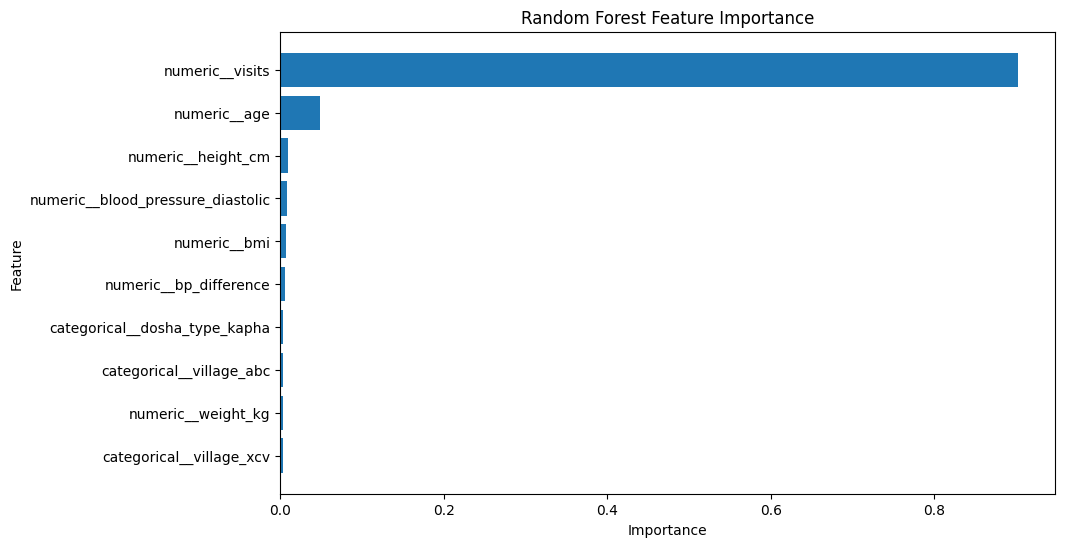

In [59]:
#First inspect
rf_model = tuned_model.named_steps["model"]

#Transformed feature names:
feature_names = (
    tuned_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

#Then:
importance = rb.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
"Importance",
ascending=False
)

importance.head(15)

#Plot:
fcb.figure(figsize=(10,6))

fcb.barh(
    importance.head(10)["Feature"],
    importance.head(10)["Importance"]
)

fcb.xlabel("Importance")
fcb.ylabel("Feature")
fcb.title("Random Forest Feature Importance")

fcb.gca().invert_yaxis()
fcb.show()

##STEP 28

##EXERCISE

1.   What is the difference between a feature being useful for prediction and a feature causing the outcome?
*    Useful for prediction: Helps the model make accurate prediction.

Causing the outcome: Directly influences the outcome.

##STEP 25

In [60]:
#Creating a simple table:

experiment_log = rb.DataFrame([
    {
        "Experiment": "Random Forest Baseline",
        "CV": "5-fold",
        "Tuning": "No",
        "Test_RMSE": baseline_metrics["RMSE"],
        "Test_R2": baseline_metrics["R2"]
    },
    {
        "Experiment": "Random Forest Tuned",
        "CV": "5-fold",
        "Tuning": "GridSearchCV",
        "Test_RMSE": tuned_metrics["RMSE"],
        "Test_MAE": tuned_metrics["MAE"],
        "Test_R2": tuned_metrics["R2"]
    }
])

experiment_log
#Save:

experiment_log.to_csv(
    "day6_experiment_results.csv",
    index=False
)

##STEP 26

In [61]:
import joblib

joblib.dump(
    tuned_model,
    "day6_tuned_random_forest_pipeline.pkl"
)


['day6_tuned_random_forest_pipeline.pkl']

##STEP 27

In [62]:
loaded_model = joblib.load(
    "day6_tuned_random_forest_pipeline.pkl"
)
#Predict:

loaded_pred = loaded_model.predict(
    x_test
)
#Verify:

kb.allclose(
    tuned_pred,
    loaded_pred
)

#Expected:
True

True

##EXERCISE


1.   Explain why getting True is useful.
*    True verifies that the saved model works correctly and has preserved the trained model and preprocessing pipeline.


##STEP 28



1.   Why is reproductibility important in machine learning engineering?
*    Reproducibility is important because it allows us to repeat, verify, debug, and trust our machine learning results.





##STEP 29

In [63]:
#For example
cv= 3

#instead of:
cv = 5

#Record:

#Experiment A
CV= 5

#Experiment B
CV= 3




1.   Did the selected parameters change?
*    They may change because using 3 folds instead of 5 can give different training/validation splits.

2.   Did the CV score change?
*    It may change because the model is evaluated on different folds.

3.   Why might different folds produce different results?
*    Each fold contains different data, and your dataset is small, so changing the folds can noticeably affect the results.

4.   Which setup would you document and why?
*    Experiment B.


##DAY 6 MINI PROJECT

In [64]:
import pandas as rb
import numpy as kb
import matplotlib.pyplot as fcb
csv_text = """patient_id,age,village,dosha_type,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,consultation_fee
P001,21,abc,kapha,56,150,110,80,4,400
P002,55,qwe,vata,55,167,120,70,3,300
P003,24,bnm,kapha,76,170,140,90,4,400
P004,34,mnb,vata,64,145,130,100,5,500
P005,76,abc,pitta,54,170,120,90,4,400
P006,33,abc,vata,77,169,130,100,2,200
P007,32,lkj,pitta,80,150,120,90,5,500
P008,66,hgf,kapha,86,144,140,100,3,300
P009,23,poi,pitta,46,150,140,100,4,400
P010,19,yui,vata,46,167,130,90,2,200
P011,45,lkj,pitta,76,163,120,80,3,300
P012,32,dfg,vata,55,150,110,90,5,500
P013,29,xcv,kapha,75,157,120,100,1,100
P014,34,vgy,vata,65,159,120,90,4,400
P015,26,wdv,vata,56,160,110,80,2,200
P016,54,ggf,kapha,54,165,110,90,3,300
P017,23,hdd,vata,63,170,120,90,4,400
P018,42,yug,kapha,66,180,110,90,2,200
P019,32,ghu,None,56,160,110,100,5,500
P020,34,None,pitta,54,170,110,80,3,300
P021,23,hdg,pitta,54,180,120,90,2,200
P022,53,ghg,vata,55,159,110,90,3,300
P023,35,abc,kapha,75,146,110,70,6,600
P024,44,abc,vata,86,168,120,80,3,300
P025,27,hjg,pitta,56,175,120,90,4,400
P026,25,kxs,kapha,46,187,130,100,5,500
P027,34,cxj,vata,74,190,120,90,3,300
P028,45,gfx,pitta,50,165,130,100,5,500
P029,26,wdv,vata,56,167,110,80,2,200
P030,23,hdd,vata,63,173,120,90,4,400
"""

with open("health_camp.csv", "w") as f:
  f.write(csv_text)
df = rb.read_csv("health_camp.csv")
df

,patient_id,age,village,dosha_type,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,consultation_fee
0,P001,21,abc,kapha,56,150,110,80,4,400
1,P002,55,qwe,vata,55,167,120,70,3,300
2,P003,24,bnm,kapha,76,170,140,90,4,400
3,P004,34,mnb,vata,64,145,130,100,5,500
4,P005,76,abc,pitta,54,170,120,90,4,400
5,P006,33,abc,vata,77,169,130,100,2,200
6,P007,32,lkj,pitta,80,150,120,90,5,500
7,P008,66,hgf,kapha,86,144,140,100,3,300
8,P009,23,poi,pitta,46,150,140,100,4,400
9,P010,19,yui,vata,46,167,130,90,2,200


In [65]:
#Inspecting the dataset

df.head()
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   patient_id                30 non-null     object
 1   age                       30 non-null     int64 
 2   village                   29 non-null     object
 3   dosha_type                29 non-null     object
 4   weight_kg                 30 non-null     int64 
 5   height_cm                 30 non-null     int64 
 6   blood_pressure_systolic   30 non-null     int64 
 7   blood_pressure_diastolic  30 non-null     int64 
 8   visits                    30 non-null     int64 
 9   consultation_fee          30 non-null     int64 
dtypes: int64(7), object(3)
memory usage: 2.5+ KB


,age,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,consultation_fee
count,30.000000,30.000000,30.00000,30.000000,30.000000,30.000000,30.000000
mean,35.633333,62.500000,164.20000,120.333333,89.333333,3.500000,350.000000
std,13.884954,11.880874,11.93777,9.643055,8.683450,1.224745,122.474487
min,19.000000,46.000000,144.00000,110.000000,70.000000,1.000000,100.000000
25%,25.250000,54.250000,157.50000,110.000000,82.500000,3.000000,300.000000
50%,32.500000,56.000000,166.00000,120.000000,90.000000,3.500000,350.000000
75%,43.500000,74.750000,170.00000,127.500000,97.500000,4.000000,400.000000
max,76.000000,86.000000,190.00000,140.000000,100.000000,6.000000,600.000000


In [66]:
#Checking missing values

df.isnull().sum()

,0
patient_id,0
age,0
village,1
dosha_type,1
weight_kg,0
height_cm,0
blood_pressure_systolic,0
blood_pressure_diastolic,0
visits,0
consultation_fee,0


In [67]:
#Checking duplicate rows

df.duplicated().sum()

np.int64(0)

In [68]:
#Identifying numerical and categorical features

x = df.drop("consultation_fee", axis=1)
y = df["consultation_fee"]

numerical_features = x.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = x.select_dtypes(
    include=["object"]
).columns

print("Numerical:", list(numerical_features))
print("Categorical:", list(categorical_features))

Numerical: ['age', 'weight_kg', 'height_cm', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'visits']
Categorical: ['patient_id', 'village', 'dosha_type']


In [69]:
#Feature Engineering BMI

df["BMI"] = df["weight_kg"]/ (df["height_cm"]/100)**2

In [70]:
#Feature Engineering Pulse Pressure

df["pulse_pressure"] = (
    df["blood_pressure_systolic"] -
    df["blood_pressure_diastolic"]
)

In [71]:
df.head()

,patient_id,age,village,dosha_type,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,visits,consultation_fee,BMI,pulse_pressure
0,P001,21,abc,kapha,56,150,110,80,4,400,24.888889,30
1,P002,55,qwe,vata,55,167,120,70,3,300,19.721037,50
2,P003,24,bnm,kapha,76,170,140,90,4,400,26.297578,50
3,P004,34,mnb,vata,64,145,130,100,5,500,30.439952,30
4,P005,76,abc,pitta,54,170,120,90,4,400,18.685121,30


##Explain possible data leakage.

*    Data leakage happens when information from test data accidentally used when training the model.



In [72]:
#Performing a train/test split
x = df.drop("consultation_fee", axis=1)
y = df["consultation_fee"]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print(x_train.shape)
print(x_test.shape)

(24, 11)
(6, 11)


In [73]:
#Building preprocessing pipeline

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


x_train = x_train.drop("patient_id", axis=1, errors= "ignore")
x_test = x_test.drop("patient_id", axis=1, errors= "ignore")

numerical_features = x_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = x_train.select_dtypes(
    include=["object"]
).columns


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [74]:
print(x_train.shape)
print(x_test.shape)

print(numerical_features)
print(categorical_features)

(24, 10)
(6, 10)
Index(['age', 'weight_kg', 'height_cm', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'visits', 'BMI', 'pulse_pressure'],
      dtype='object')
Index(['village', 'dosha_type'], dtype='object')


In [75]:
#Training a Random Forest Baseline

from sklearn.ensemble import RandomForestRegressor

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

baseline_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['age', 'weight_kg', 'height_cm', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'visits', 'BMI', 'pulse_pressure'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['village', 'dosha_type'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [76]:
#Performing 5 fold cross-validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    baseline_model,
    x_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

cv_score = -cv_scores
print("CV Scores:", cv_scores)

CV Scores: [-34.2  -41.6   -9.   -20.8  -11.25]


In [77]:
#Reporting mean and standard deviation

print("Mean MAE", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Mean MAE -23.37
Standard Deviation: 12.724920431971276


In [78]:
##Defining hyperparameter search space

#The list of possible values the model tests to find the best settings.

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}

In [79]:
#Using GridSearchCV

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    baseline_model,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         Index(['age', 'weight_kg', 'height_cm', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'visits', 'BMI', 'pulse_pressure'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['village', 'dosha_type'], dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='neg_mean_absolute_error')

In [80]:
#Identifying the best CV configuration

print(grid_search.best_params_)

print(-grid_search.best_score_)

{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
22.9


In [81]:
#Evaluating the tuned model on the test set

tuned_model = grid_search.best_estimator_
y_pred = tuned_model.predict(x_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as kb

mae = mean_absolute_error(y_test, y_pred)
rmse = kb.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 7.833333333333333
RMSE: 12.058883309273154
R2: 0.9872317073170732


In [82]:
#Comparing default and tuned model

baseline_pred = baseline_model.predict(x_test)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

tuned_mae = mean_absolute_error(
    y_test,
    y_pred
)

print("Baseline MAE:", baseline_mae)
print("Tuned MAE:", tuned_mae)

Baseline MAE: 7.333333333333333
Tuned MAE: 7.833333333333333


In [83]:
#Comparing training and test performance

train_pred = tuned_model.predict(x_train)

train_mae = mean_absolute_error(
    y_train,
    train_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_pred
)

print("Training MAE:", train_mae)
print("Test MAE:", test_mae)

Training MAE: 6.666666666666667
Test MAE: 7.833333333333333


In [84]:
#Inspecting 5 prediction errors

errors = rb.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
errors["Error"] = (
    errors["Actual"] - errors["Predicted"]
)

errors["Absolute_Error"] = abs(errors["Error"])

errors.sort_values(
    by="Absolute_Error",
    ascending=False
).head(5)

,Actual,Predicted,Error,Absolute_Error
3,200,228.0,-28.0,28.0
4,400,406.0,-6.0,6.0
1,300,294.5,5.5,5.5
0,500,504.0,-4.0,4.0
2,300,298.0,2.0,2.0


In [85]:
#Generating feature importance

model = tuned_model.named_steps["model"]
preprocessor_fitted =(
    tuned_model.named_steps["preprocessor"]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

importance = rb.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
5,num__visits,0.906963
0,num__age,0.046717
2,num__height_cm,0.009517
6,num__BMI,0.006456
4,num__blood_pressure_diastolic,0.006319
7,num__pulse_pressure,0.005487
25,cat__dosha_type_kapha,0.003897
8,cat__village_abc,0.003413
1,num__weight_kg,0.003186
24,cat__village_xcv,0.002613


In [86]:
#Saving Experiment results

results = rb.DataFrame({
    "Metrics": [
        "Baseline MAE",
        "Tuned MAE",
        "Test RMSE",
        "Test R2"
      ]
})

results.to_csv(
    "experiment_results.csv",
    index=False
)

In [87]:
#Saving the complete tuned pipeline

import joblib
joblib.dump(
    tuned_model,
    "tuned_health_camp_pipeline.pkl"

)

['tuned_health_camp_pipeline.pkl']

In [88]:
#Reloading the pipeline

loaded_model = joblib.load(
    "tuned_health_camp_pipeline.pkl"
)

In [89]:
#Verifying predictions after reloading

loaded_predictions = loaded_model.predict(x_test)

print("Original:")
print(y_pred[:5])

print("Reloaded:")
print(loaded_predictions[:5])

Original:
[504.  294.5 298.  228.  406. ]
Reloaded:
[504.  294.5 298.  228.  406. ]


#Writing 5 observations


*    The dataset conatins 30 fictional records.
*    consultation_fee is the target variable.
*    Missing values are present in some categorical columns.
*    BMI and pulse pressure were created through feature engineering.
*    RandomForest was used for consultation_fee prediction.

##Writing 3 limitations.



*    The dataset contains only 30 records which is kinda small for real world projects.
*    The dataset is fictional.
*    The dataset is small, so it may not generalize well to a larger real-world dataset.


##Writing 3 future improvements



*    Collect more big dataset and use real world records.
*    Add more meaningful features and all.
*    Test additional regression algorithms and comparing their performances.


##DAY 6 Learning Report

#Topics Learned

*    Feature engineering.
*    Feature leakage.
*    Cross-validation.
*    K-Fold Cross-Validation
*    Validation data.
*    Hyperparameters.
*    GridSearchCV.
*    Random Forest tuning.
*    Experiment tracking.
*    Feature importance.
*    Reproductibility.
*    Final test evaluation.

##Prediction problem:
Using a feature to predict a target value is known as prediction problem.

##Feature Used:
#List the original and engineered features. Explain why each group was selected.

Original features:
age, weight_kg, height_cm, blood_pressure_systolic, blood_pressure_diastolic, village, visits, dosha_type.

Engineered features:
height_m, BMI, bp_difference.

The original features are directly available in the dataset. They provide basic patient information which may help to find the target.


The engineered features were added from the existing dataset to provide additional information.

##Feature Engineering


*    BMI
BMI is a value calculated using weight and height.

*    BP difference
BP differenece is the value calculated by substracting the BP diastolic from systolic.


These are engineered feature they're created from existing columns which gives the model useful informations.

##Cross Validation



1.   What K-Fold Cross Validation?
*    K-Fold Cross validation is a method used to check how well the ML model works on different parts of the training data.

2.   Why it was used?
*    To check how consistently the model performs on different parts of the training data instead of relying on only one split.

3.   How many folds were used?
*    5 folds were used.

4.   The mean score.
*    This is the average of 5CV score.  (cv_mean = cv_score.mean())

5.   The standard deviation.
*    This shows how much the 5 scores vary from each other. (cv_std = cv_score.std()).


##Hyperparameter Tuning



1.   Parameters tested.
*    n_estimators, max_depth, min_samples_split.

2.   Values tested.
*    n_estimators = [100, 200],
     max_depth = [None, 5, 10],
     min_samples_split = [2, 5, 10]

3.   Number of combinations.
*    2x3x3 = 18, counting values for each parameters.

4.   Best parameters.
*    Get from grid_search.best_params_.



In [90]:
##Calculating Default Random Forest

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import numpy as kb

default_cv = cross_val_score(
    baseline_model,
    x_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)
default_cv_rmse = -default_cv.mean()

default_pred = baseline_model.predict(x_test)

default_test_rmse = kb.sqrt(
    mean_squared_error(y_test, default_pred)
)

default_test_mae = mean_absolute_error(
    y_test, default_pred
)
default_test_r2 = r2_score(
    y_test, default_pred
)

print("Default Random Forest")
print("CV RMSE:", default_cv_rmse)
print("Test RMSE:", default_test_rmse)
print("Test MAE:", default_test_mae)
print("Test R2:", default_test_r2)

Default Random Forest
CV RMSE: 33.85025302543097
Test RMSE: 12.0
Test MAE: 7.333333333333333
Test R2: 0.9873560975609756


In [91]:
#Calculating Tuned Random Forest

tuned_model = grid_search.best_estimator_

# CV RMSE for tuned model
tuned_cv = cross_val_score(
    tuned_model,
    x_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

tuned_cv_rmse = -tuned_cv.mean()

# Test prediction
tuned_pred = tuned_model.predict(x_test)

tuned_test_rmse = kb.sqrt(
    mean_squared_error(y_test, tuned_pred)
)

tuned_test_mae = mean_absolute_error(
    y_test, tuned_pred
)

tuned_test_r2 = r2_score(
    y_test, tuned_pred
)

print("Tuned Random Forest")
print("CV RMSE:", tuned_cv_rmse)
print("Test RMSE:", tuned_test_rmse)
print("Test MAE:", tuned_test_mae)
print("Test R2:", tuned_test_r2)



Tuned Random Forest
CV RMSE: 32.6537318313077
Test RMSE: 12.058883309273154
Test MAE: 7.833333333333333
Test R2: 0.9872317073170732


##Did tuning help?
Hyperparameter tuning was used to find a better RF configuration. The default and tuned models were compared using CV RMSE, test RMSE, test MAE, and R2. IF the tuned model has lower RMSE and MAE and higher R2, tuning improved the model's performance.

#Important patterns i found

*    visits is strongly related to consultation_fee i  this dataset.
*    The engineered feature BMI adds information about the patient's body measurements.
*    BP difference provides an additional blood pressure info.
*    The RF can captiure non-linear relationships between the features and consultation fee.
*    The dataset is kinda small.



##Feature Importance

Feature importance shows which features contributed most to the Random Forest’s predictions. The feature with the highest importance had the largest contribution to reducing prediction error within the trees. In this dataset, visits is expected to be highly important because consultation fee increases with the number of visits. However, feature importance shows association with model predictions and does not prove causation.

In [92]:
##Largest prediction error

errors.sort_values(
    "Absolute_Error",
    ascending= False
).head(5)


#I inspected the five predictions with the largest absolute errors. You can see i got the largest error 28. These errors were measured using the difference between actual and predicted values.

,Actual,Predicted,Error,Absolute_Error
3,200,228.0,-28.0,28.0
4,400,406.0,-6.0,6.0
1,300,294.5,5.5,5.5
0,500,504.0,-4.0,4.0
2,300,298.0,2.0,2.0


##Possible Limitations

*    The dataset is small, containing only 30 records.
*    The data is synthetic and may not represent real-world healthcare data.
*    Only a limited number of patient features are available.

##Problems i faced

I faced problems while handling missing categorical values and preparing the preprocessing pipeline. I also had to make sure that categorical features were encoded correctly before training the RF.

##How i solved them

I used SimpleImputer to handle missing values and OneHotEncoder for categorical variables. I combined these steps with the Random Forest using a Pipeline and ColumnTransformer. I used 5-fold cross-validation and GridSearchCV to tune the model while keeping the test set untouched. Finally, i compared the models using RMSE, MAE and R2.

##Questions i still have



1.   How can i reduce overfitting in RandomForest?

2.   How can i handle outliers more effectively?

3.   How can i use this model with new patient data?

4.   How can i compare more than two machine-learning models?


##CONCLUSION


Day 6 helped me understand how to improve and evaluate a ML model. I lwarned about preprocessing, cross-validation, and hyperparameter tuning. I kept the test data seperate to get a fair evaluation. I also learned how to save the model and keep my results reproducible and documented.

##FINAL DAY 6

1.   What is cross-validation?
*    Cross-validation is a technique used to check how well a ML model performs on different parts of training data. (Use different parts of the data for validation multiple times.)

2.   Why is a single train/test split sometimes insufficient?
*    A single train/test split sometimes be insufficient because the result depends heavily on which data happens to go into the training and test sets.

3.   What is K-Fold Cross-Validation?
*    K-Fold Cross-Validation is a technique used to check how well a machine learning model performs on different parts of the training data by dividing the data into K groups. (Divide the data into K-groups and use each group once for validation.)

4.   What does cv=5 mean?
*    It means that the data is divided into 5 folds.

5.   What is the purpose of a validation set?
*    It is used to compare and tune models before final testing.

6.   Why should the test set remain untouched during hyperparameter tuning?
*    The test set should be remain untouched during hyperparameter tuning because it can cause data leakage

7.   What is feature engineering?
*    Feature engineering means creating new useful features from existing feature.

8.   Give two examples of engineered features from today's dataset.
*    BMI and Pulse pressure.

9.   What is feature leakage?
*    Feature leakage happens when information that should not be available when making a prediction is used by the model.

10.   Give one example of potential leakage.
*     Using info collected after the consultation fee was decided to predict the consultation fee.

11.   What is a hyperparameter?
*     A hyperparameter is a setting of a model that is chosen before training.

12.   Give three Random Forest hyperparameters.
*     n_estimators, max-depth, min_samples_split.

13.   What is GridSearchCV?
*     GridSearchCV is a method used to find the best hyperparameter methods for a ML model.

14.   Why is the pipeline passed into GridSearchCV?
*     Preprocessing and model training are performed correctly inside each cross-validation fold, helping prevent leakage.

15.   What does model__n_estimators mean?
*     It is the number of decision trees in the Random Forest.

16.   What does best_params_represent?
*     It represents the best hyperparameter setting that gave the best result.

17.   What does best_score_represent?
*     It is the best average cross-validation score obtained during GridSearchCV.

18.   Why can a better CV score still be followed by a worse test result?
*     Because the test data may be different from the validation folds, and the model may not generalize perfectly.

19.   Why should training and testing performance be compared?
*     To check whether the model generalized well to unseen data.

20.   What can a large train/test performance gap indicate?
*     Overfitting.

21.   What is feature importance?
*     Features importance shows how much each feature contributes to the model's predictions.

22.   Does feature importance prove causation?
*     Nope.

23.   Why should experiments be documented?
*     Documentation heps us track, compare, and reproduce our ML experiments.

24.   Why should a complete pipeline be saved?
*     A complete pipeline should be saved because the same preprocessing and model can be reused without repeating the entire process.

25.   Why should the saved pipeline be reloaded and tested?
*    The pipeline should be reloaded and tested because to make sure the saved model works correctly after loading and gives the expected predictions.

26.   Why is reproducibility important?
*     Reproducibility is important which allows us to repeat the same experiment and get consistent results.

27.   Why should we avoid tuning repeatedly against the test set?
*     We should avoid tuning repeatedly against the test set because the model can become indirectly overfitted to the test set.

28.   Why is a high R² on a synthetic dataset not proof of clinical usefulness?
*     An high R² on a synthetic dataset is not proof of clinical usefulness because it is fictional data and not conatin any real-patients conditions.

29.   What is the difference between a model being useful for this exercise and being production-ready?
*     For this exercise, the model demonstrate the ML workflow. A production ready model needs real world validations, reliable data, testing and monitoring.

30.   Explain the complete Day 6 machine learning workflow.
*     Day 6 focused on building a complete ML workflow. First we inspected and cleaned the dataset, then checked missing and duplicated values, identified numerical and categorical feature and defined the target.